In [61]:
import numpy
from tensorflow import keras
from sklearn.preprocessing import OneHotEncoder
from keras.models import Sequential, load_model
from keras.layers import Conv2D, MaxPool2D, Dense, Dropout, Flatten
from keras.layers import BatchNormalization
from keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix
from keras.utils import to_categorical
from keras.datasets import cifar10
import matplotlib.pyplot as plt

In [62]:
(x_train, y_train),(x_test, y_test)=cifar10.load_data()

In [63]:
x_train.shape

(50000, 32, 32, 3)

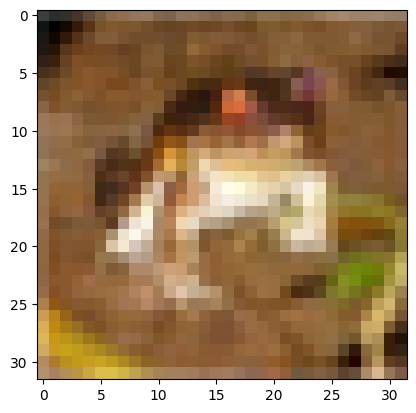

In [64]:
plt.imshow(x_train[0])

In [65]:
x_train = x_train/ 255.0
x_test = x_test / 255.0

In [66]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [67]:
num_class=y_train[1].shape
num_class

(10,)

In [68]:
x_train.shape[1:]

(32, 32, 3)

In [69]:
model=Sequential()
model.add(Conv2D(32, (3,3), padding='same', input_shape=(x_train.shape[1:]), activation='relu' ))
model.add(Dropout(0.2))
model.add(BatchNormalization())

model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(MaxPool2D(2))
model.add(Dropout(0.2))
model.add(BatchNormalization())

model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(MaxPool2D(2))
model.add(Dropout(0.1))
model.add(BatchNormalization())

model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(MaxPool2D(2))
model.add(Dropout(0.2))
model.add(BatchNormalization())

model.add(Flatten())
model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))
model.add(BatchNormalization())

model.add(Dense(num_class[0], activation='softmax'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [70]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics = ['accuracy'], )

In [71]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │        65,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 197,354 (770.91 KB)

 Trainable params: 196,714 (768.41 KB)

 Non-trainable params: 640 (2.50 KB)

In [72]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# EarlyStopping: توقف زودهنگام وقتی که بهبودی در val_loss دیده نمی‌شه
early_stop = EarlyStopping(
    monitor='val_loss',      # یا 'val_accuracy' بسته به هدف
    patience=5,              # چند epoch صبر کنه بعد متوقف شه
    restore_best_weights=True,  # بهترین وزن‌ها رو برگردونه
    verbose=1
)

# ModelCheckpoint: ذخیره بهترین مدل (بر اساس val_loss)
model_checkpoint = ModelCheckpoint(
    filepath='best_model.h5',   # محل ذخیره مدل
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

# ReduceLROnPlateau: وقتی مدل گیر می‌کنه، نرخ یادگیری رو کاهش بده
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,          # نرخ یادگیری رو نصف کن
    patience=3,          # چند epoch صبر کنه بدون بهبود بعد کاهش بده
    verbose=1
)

In [73]:
history=model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=30, batch_size=64,  callbacks=[early_stop, model_checkpoint, reduce_lr])

Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3521 - loss: 1.8298
Epoch 1: val_loss improved from inf to 1.25292, saving model to best_model.h5


782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 18ms/step - accuracy: 0.3522 - loss: 1.8294 - val_accuracy: 0.5643 - val_loss: 1.2529 - learning_rate: 0.0010
Epoch 2/30
776/782 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5828 - loss: 1.1832
Epoch 2: val_loss improved from 1.25292 to 1.00064, saving model to best_model.h5


782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5829 - loss: 1.1828 - val_accuracy: 0.6456 - val_loss: 1.0006 - learning_rate: 0.0010
Epoch 3/30
778/782 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6516 - loss: 0.9895
Epoch 3: val_loss improved from 1.00064 to 0.87227, saving model to best_model.h5


782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.6517 - loss: 0.9894 - val_accuracy: 0.6920 - val_loss: 0.8723 - learning_rate: 0.0010
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6937 - loss: 0.8742
Epoch 4: val_loss did not improve from 0.87227
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6938 - loss: 0.8742 - val_accuracy: 0.6848 - val_loss: 0.8982 - learning_rate: 0.0010
Epoch 5/30
777/782 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7131 - loss: 0.8266
Epoch 5: val_loss improved from 0.87227 to 0.67495, saving model to best_model.h5


782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7131 - loss: 0.8265 - val_accuracy: 0.7649 - val_loss: 0.6750 - learning_rate: 0.0010
Epoch 6/30
779/782 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7350 - loss: 0.7716
Epoch 6: val_loss improved from 0.67495 to 0.64808, saving model to best_model.h5


...

782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8362 - loss: 0.4745 - val_accuracy: 0.8325 - val_loss: 0.4901 - learning_rate: 5.0000e-04
Epoch 22/30
777/782 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8456 - loss: 0.4519
Epoch 22: val_loss did not improve from 0.49011
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8455 - loss: 0.4520 - val_accuracy: 0.8286 - val_loss: 0.4987 - learning_rate: 5.0000e-04
Epoch 23/30
778/782 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8423 - loss: 0.4569
Epoch 23: val_loss improved from 0.49011 to 0.47924, saving model to best_model.h5


782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8423 - loss: 0.4569 - val_accuracy: 0.8367 - val_loss: 0.4792 - learning_rate: 5.0000e-04
Epoch 24/30
778/782 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8466 - loss: 0.4409
Epoch 24: val_loss did not improve from 0.47924
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8465 - loss: 0.4410 - val_accuracy: 0.8288 - val_loss: 0.5065 - learning_rate: 5.0000e-04
Epoch 25/30
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8429 - loss: 0.4503
Epoch 25: val_loss did not improve from 0.47924
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8429 - loss: 0.4503 - val_accuracy: 0.8379 - val_loss: 0.4874 - learning_rate: 5.0000e-04
Epoch 26/30
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8470 - loss: 0.4394
Epoch 26: val_loss did not improve from 0.47924

Epoch 26: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8470 - loss: 0.4394 - va

782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8525 - loss: 0.4281 - val_accuracy: 0.8405 - val_loss: 0.4707 - learning_rate: 2.5000e-04
Epoch 28/30
779/782 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8529 - loss: 0.4170
Epoch 28: val_loss improved from 0.47074 to 0.46997, saving model to best_model.h5


782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8529 - loss: 0.4170 - val_accuracy: 0.8427 - val_loss: 0.4700 - learning_rate: 2.5000e-04
Epoch 29/30
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8569 - loss: 0.4118
Epoch 29: val_loss improved from 0.46997 to 0.46785, saving model to best_model.h5


782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8569 - loss: 0.4118 - val_accuracy: 0.8418 - val_loss: 0.4678 - learning_rate: 2.5000e-04
Epoch 30/30
780/782 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8571 - loss: 0.4088
Epoch 30: val_loss did not improve from 0.46785
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8571 - loss: 0.4088 - val_accuracy: 0.8419 - val_loss: 0.4779 - learning_rate: 2.5000e-04
Restoring model weights from the end of the best epoch: 29.


In [74]:
import pandas as pd

<Axes: >

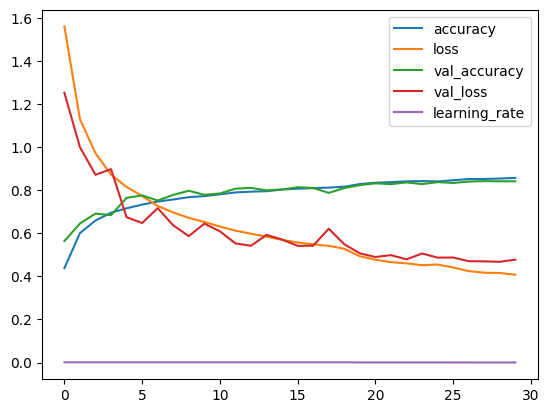

In [75]:
pd.DataFrame(history.history).plot()